In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
from sklearn.model_selection import train_test_split

In [2]:
df = sns.load_dataset('iris')
print(df.info())
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [3]:
x_cols = ['sepal_length', 'sepal_width']
y_cols = ['petal_length', 'petal_width']
X_raw = df[x_cols].to_numpy()
Y_raw = df[y_cols].to_numpy()


X = StandardScaler().fit_transform(X_raw)
Y = StandardScaler().fit_transform(Y_raw)

print('n наблюдений:', X.shape[0])
print('признаков в блоке X:', X.shape[1], '| признаков в блоке Y:', Y.shape[1])


n наблюдений: 150
признаков в блоке X: 2 | признаков в блоке Y: 2


In [4]:
n_components = min(X.shape[1], Y.shape[1])  # не больше числа признаков в меньшем блоке
cca = CCA(n_components=n_components)
cca.fit(X, Y)
X_c, Y_c = cca.transform(X, Y)  # канонические переменные (score) для X и Y

print('Число канонических пар:', n_components)
print('Форма X_c:', X_c.shape, '| форма Y_c:', Y_c.shape)


Число канонических пар: 2
Форма X_c: (150, 2) | форма Y_c: (150, 2)


In [5]:
canon_corrs = [np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1] for i in range(n_components)]
for i, r in enumerate(canon_corrs, start=1):
    print(f'Каноническая корреляция {i}-й пары: r = {r:.3f}')


Каноническая корреляция 1-й пары: r = 0.941
Каноническая корреляция 2-й пары: r = 0.124


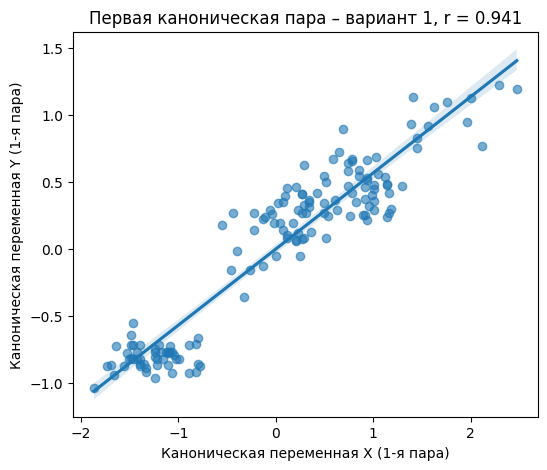

In [8]:
plt.figure(figsize=(6, 5))
sns.regplot(x=X_c[:, 0], y=Y_c[:, 0], scatter_kws={'alpha': 0.6})
plt.xlabel('Каноническая переменная X (1-я пара)')
plt.ylabel('Каноническая переменная Y (1-я пара)')
plt.title(f'Первая каноническая пара – вариант 1, r = {canon_corrs[0]:.3f}')
plt.savefig('cca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
X1, X2, Y1, Y2 = train_test_split(X, Y, test_size=0.5, random_state=1)

cca1 = CCA(n_components=n_components).fit(X1, Y1)
X1_c, Y1_c = cca1.transform(X1, Y1)
r1 = np.corrcoef(X1_c[:, 0], Y1_c[:, 0])[0, 1]

cca2 = CCA(n_components=n_components).fit(X2, Y2)
X2_c, Y2_c = cca2.transform(X2, Y2)
r2 = np.corrcoef(X2_c[:, 0], Y2_c[:, 0])[0, 1]

print(f'Полная выборка: r = {canon_corrs[0]:.3f}')
print(f'Половина 1: r = {r1:.3f}  |  Половина 2: r = {r2:.3f}')


Полная выборка: r = 0.941
Половина 1: r = 0.939  |  Половина 2: r = 0.946
